In [72]:
import cv2
from pathlib import Path
import numpy as np
import json
import pandas as pd
from mmdet.apis import inference_detector, init_detector
from IPython.display import display 
import matplotlib.pyplot as plt

In [26]:
config_path = Path(r"C:\dev\projects\CV_counting_bags\configs\rtmdet_tiny_bag.py")
ckpt_path = Path(r"C:\dev\projects\CV_counting_bags\work_dirs\rtmdet_tiny_bag\best_coco_bbox_mAP_epoch_27.pth")
video_path = Path(r"C:\dev\projects\CV_counting_bags\input.mp4")
ann_path = Path(r"C:\dev\projects\CV_counting_bags\dataset\annotations\instances_val.json")
images_dir_path = Path(r"C:\dev\projects\CV_counting_bags\dataset\val")

In [8]:
model = init_detector(
    str(config_path),
    str(ckpt_path),
    device = "cuda:0"
)

Loads checkpoint by local backend from path: C:\dev\projects\CV_counting_bags\work_dirs\rtmdet_tiny_bag\best_coco_bbox_mAP_epoch_27.pth


In [29]:
with open(ann_path, "r", encoding = "utf-8") as ann_file:
    coco_data = json.load(ann_file)

images = coco_data['images']
annotations = coco_data['annotations']

anns_by_image = {}

for ann in annotations:
    anns_by_image.setdefault(ann['image_id'], []).append(ann)

In [25]:
def bbox_iou(bbox1, bbox2):
    x1 = max(bbox1[0], bbox2[0])
    y1 = max(bbox1[1], bbox2[1])
    x2 = min(bbox1[2], bbox2[2])
    y2 = min(bbox1[3], bbox2[3])

    inter_width = max(0, x2 - x1)
    inter_height = max(0, y2 - y1)

    area1 = max(0, bbox1[2] - bbox1[0]) * max(0, bbox1[3] - bbox1[1])
    area2 = max(0, bbox2[2] - bbox2[0]) * max(0, bbox2[3] - bbox2[1])

    intersection = inter_width * inter_height
    union = area1 + area2 - intersection
    
    if union == 0:
        return 0.0

    return intersection / union

In [68]:
predictions = {}

for i, img_info in enumerate(images):
    img_id = img_info['id']
    file_name = img_info['file_name']

    image_path = images_dir_path / Path(file_name).name
    frame = cv2.imread(str(image_path))

    if frame is None:
        print("frame not found:", image_path)
        continue

    result = inference_detector(model, frame)

    pred = result.pred_instances
    bboxes = pred.bboxes.detach().cpu().numpy()
    scores = pred.scores.detach().cpu().numpy()

    predictions[img_id] = {
        "bboxes": bboxes,
        "scores": scores,
    }

In [56]:
def evaluate_threshold(threshold, iou_threshold):
    TP = 0
    FP = 0
    FN = 0

    for img_info in images:
        img_id = img_info['id']

        true_annotations = anns_by_image.get(img_id, [])
        true_bboxes = []

        for ann in true_annotations:
            x, y, w, h = ann['bbox']
            true_bboxes.append([x, y, x + w, y + h])

        true_bboxes = np.array(true_bboxes, dtype = float)

        if img_id not in predictions:
            continue

        pred_bboxes = predictions[img_id]['bboxes']
        pred_scores = predictions[img_id]['scores']

        mask = pred_scores >= threshold

        pred_bboxes = pred_bboxes[mask]
        pred_scores = pred_scores[mask]

        order = np.argsort(-pred_scores)
        pred_bboxes = pred_bboxes[order]

        matched_true = set()

        for pred_bbox in pred_bboxes:
            best_iou = 0
            best_true_idx = None

            for true_idx, true_bbox in enumerate(true_bboxes):
                if true_idx in matched_true:
                    continue

                iou = bbox_iou(pred_bbox, true_bbox)

                if iou > best_iou:
                    best_iou = iou
                    best_true_idx = true_idx

            if best_iou >= iou_threshold:
                TP += 1
                matched_true.add(best_true_idx)

            else:
                FP += 1

        FN += len(true_bboxes) - len(matched_true)

    precision = TP / (TP + FP) if TP + FP > 0 else 0
    recall = TP / (TP + FN) if TP + FN > 0 else 0

    f1 = (
        2 * precision * recall / (precision + recall) if precision + recall > 0
        else 0
    )

    return {
        "threshold": threshold,
        "TP": TP,
        "FP": FP,
        "FN": FN,
        "precision": precision,
        "recall": recall,
        "F1": f1,
    }

,threshold,TP,FP,FN,precision,recall,F1
0,0.10,309,60,0,0.8374,1.0000,0.9115
1,0.15,309,24,0,0.9279,1.0000,0.9626
2,0.20,308,13,1,0.9595,0.9968,0.9778
3,0.25,306,7,3,0.9776,0.9903,0.9839
4,0.30,306,6,3,0.9808,0.9903,0.9855
5,0.35,303,5,6,0.9838,0.9806,0.9822
6,0.40,302,2,7,0.9934,0.9773,0.9853
7,0.45,300,1,9,0.9967,0.9709,0.9836
8,0.50,300,1,9,0.9967,0.9709,0.9836
9,0.55,300,1,9,0.9967,0.9709,0.9836


threshold      0.3000
TP           306.0000
FP             6.0000
FN             3.0000
precision      0.9808
recall         0.9903
F1             0.9855
Name: 4, dtype: float64

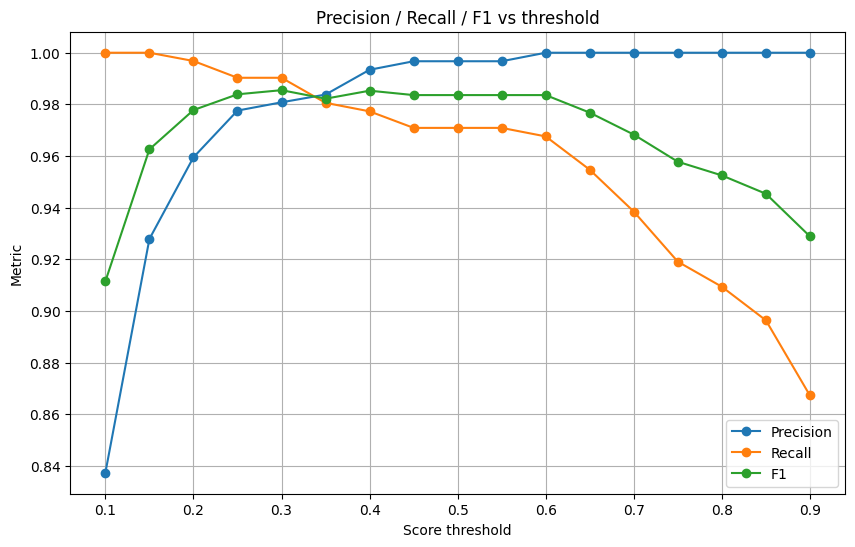

,threshold,TP,FP,FN,precision,recall,F1
0,0.10,304,65,5,0.8238,0.9838,0.8968
1,0.15,303,30,6,0.9099,0.9806,0.9439
2,0.20,302,19,7,0.9408,0.9773,0.9587
3,0.25,300,13,9,0.9585,0.9709,0.9646
4,0.30,300,12,9,0.9615,0.9709,0.9662
5,0.35,299,9,10,0.9708,0.9676,0.9692
6,0.40,298,6,11,0.9803,0.9644,0.9723
7,0.45,296,5,13,0.9834,0.9579,0.9705
8,0.50,296,5,13,0.9834,0.9579,0.9705
9,0.55,296,5,13,0.9834,0.9579,0.9705


threshold      0.4000
TP           298.0000
FP             6.0000
FN            11.0000
precision      0.9803
recall         0.9644
F1             0.9723
Name: 6, dtype: float64

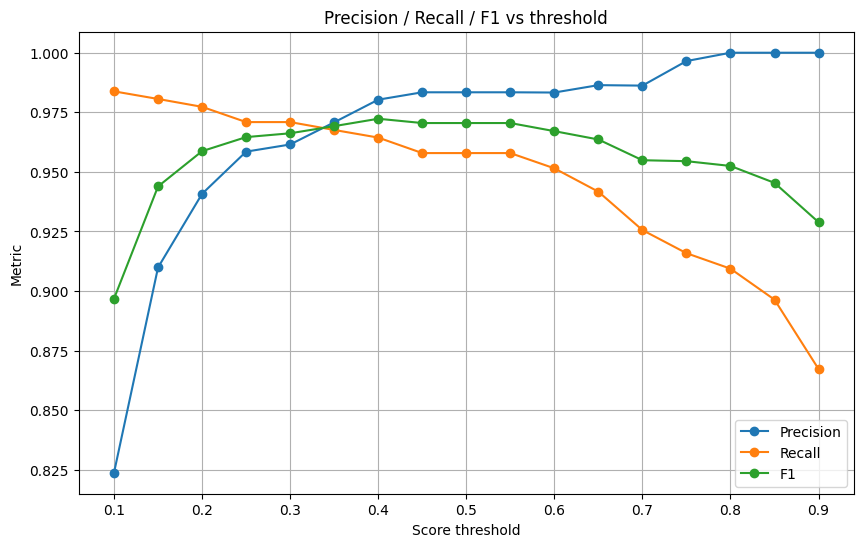

In [74]:
thresholds = np.arange(0.1, 0.91, 0.05)
for iou_threshold in [0.5, 0.75]:
    results = []

    for thr in thresholds:
        metrics = evaluate_threshold(threshold = float(thr), iou_threshold = iou_threshold)
        results.append(metrics)
    df = pd.DataFrame(results)

    for col in ["precision", "recall", "F1"]:
        df[col] = df[col].round(4)
    
    display(df)
    
    best_row = df.loc[df["F1"].idxmax()]
    display(best_row)

    plt.figure(figsize = (10, 6))

    plt.plot(df["threshold"], df["precision"], marker = "o", label = "Precision")
    plt.plot(df["threshold"], df["recall"], marker = "o", label = "Recall")
    plt.plot(df["threshold"], df["F1"], marker = "o", label = "F1")
    plt.xlabel("Score threshold")
    plt.ylabel("Metric")
    plt.title("Precision / Recall / F1 vs threshold")
    plt.grid(True)
    plt.legend()

    plt.show()

In [75]:
#0.3-0.4